In [8]:
path_figures = "../images"

# Quickstart

<Figure size 640x480 with 0 Axes>

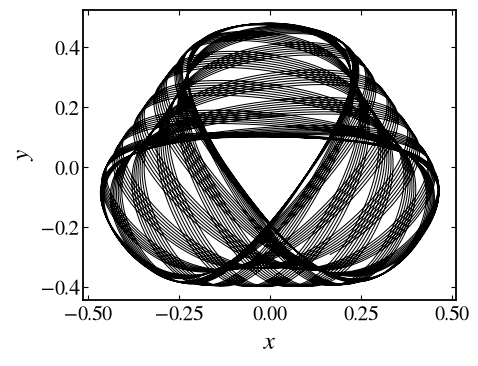

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem as hs, PlotStyler

system = hs(model="henon heiles")
system.integrator("svy4", time_step=0.01)

energy = 1.0 / 8.0
x, y, py = 0.0, 0.1, 0.0
potential = (x**2 + y**2) / 2.0 + x**2 * y - y**3 / 3.0
px = np.sqrt(2.0 * (energy - potential) - py**2)
q = [x, y]
p = [px, py]

trajectory = system.trajectory(q, p, total_time=500.0)

ps = PlotStyler(fontsize=18)
ps.apply_style()
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(trajectory[:, 1], trajectory[:, 2], "k", lw=0.75)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
fig.tight_layout()
plt.savefig(f"{path_figures}/quickstart_henon_heiles.png", dpi=400, bbox_inches="tight")

In [3]:
system.info["equation"]

<IPython.core.display.Math object>

In [4]:
system.info["equation_readable"]

'H = ½(pₓ² + pᵧ²) + ½(x² + y²) + x²y − y³/3'

# Creating a Hamiltonian system

## Using a built-in model

In [5]:
from pynamicalsys import HamiltonianSystem as hs

for model in hs.available_models():
    print(model)

henon heiles


In [6]:
system = hs(model="henon heiles")
print(system.info["degrees of freedom"])
print(system.info["parameters"])

2
[]


## Choosing a custom representation

In [7]:
for integrator in hs.available_integrators():
    print(integrator)

svy4
vv2
imp


## Creating Hénon-Heiles as a separable system

In [8]:
import numpy as np
from numba import njit
from pynamicalsys import HamiltonianSystem as hs

@njit
def henon_heiles_grad_V(q, parameters):
    x, y = q
    return np.array([x + 2.0 * x * y, y + x**2 - y**2])

@njit
def henon_heiles_grad_T(p, parameters):
    px, py = p
    return np.array([px, py])

@njit
def henon_heiles_hess_V(q, parameters):
    x, y = q
    return np.array(
        [
            [1.0 + 2.0 * y, 2.0 * x],
            [2.0 * x, 1.0 - 2.0 * y],
        ]
    )

@njit
def henon_heiles_hess_T(p, parameters):
    return np.array(
        [
            [1.0, 0.0],
            [0.0, 1.0],
        ]
    )

In [9]:
system = hs(
    grad_T=henon_heiles_grad_T,
    grad_V=henon_heiles_grad_V,
    hess_T=henon_heiles_hess_T,
    hess_V=henon_heiles_hess_V,
    degrees_of_freedom=2,
    parameters=[],
)

## Creating a general Hamiltonian system

The Walker-Ford two-resonance Hamiltonian uses action-angle variables. Pass the angles as `q` and the actions as `p`. Their coupling means that the system must use the implicit midpoint integrator.

In [10]:
import numpy as np
from numba import njit
from pynamicalsys import HamiltonianSystem as hs

@njit
def walker_ford_eom(q, p, parameters):
    theta1, theta2 = q
    J1, J2 = p
    alpha, beta = parameters

    sqrt_J2 = np.sqrt(J2)
    J2_32 = J2 * sqrt_J2
    phase_22 = 2.0 * theta1 - 2.0 * theta2
    phase_23 = 2.0 * theta1 - 3.0 * theta2
    cos_22 = np.cos(phase_22)
    cos_23 = np.cos(phase_23)
    sin_22 = np.sin(phase_22)
    sin_23 = np.sin(phase_23)

    qdot = np.empty(2)
    pdot = np.empty(2)
    qdot[0] = 1.0 - 2.0 * J1 - 3.0 * J2 + alpha * J2 * cos_22 + beta * J2_32 * cos_23
    qdot[1] = 1.0 - 3.0 * J1 + 2.0 * J2 + alpha * J1 * cos_22 + 1.5 * beta * J1 * sqrt_J2 * cos_23
    pdot[0] = 2.0 * alpha * J1 * J2 * sin_22 + 2.0 * beta * J1 * J2_32 * sin_23
    pdot[1] = -2.0 * alpha * J1 * J2 * sin_22 - 3.0 * beta * J1 * J2_32 * sin_23
    return qdot, pdot

@njit
def walker_ford_hess_H(q, p, parameters):
    theta1, theta2 = q
    J1, J2 = p
    alpha, beta = parameters

    sqrt_J2 = np.sqrt(J2)
    J2_32 = J2 * sqrt_J2
    phase_22 = 2.0 * theta1 - 2.0 * theta2
    phase_23 = 2.0 * theta1 - 3.0 * theta2
    cos_22 = np.cos(phase_22)
    cos_23 = np.cos(phase_23)
    sin_22 = np.sin(phase_22)
    sin_23 = np.sin(phase_23)

    common_22 = alpha * J1 * J2
    common_23 = beta * J1 * J2_32
    H = np.zeros((4, 4))

    H[0, 0] = -4.0 * common_22 * cos_22 - 4.0 * common_23 * cos_23
    H[1, 1] = -4.0 * common_22 * cos_22 - 9.0 * common_23 * cos_23
    H[0, 1] = 4.0 * common_22 * cos_22 + 6.0 * common_23 * cos_23
    H[1, 0] = H[0, 1]

    H[0, 2] = -2.0 * alpha * J2 * sin_22 - 2.0 * beta * J2_32 * sin_23
    H[2, 0] = H[0, 2]
    H[0, 3] = -2.0 * alpha * J1 * sin_22 - 3.0 * beta * J1 * sqrt_J2 * sin_23
    H[3, 0] = H[0, 3]
    H[1, 2] = 2.0 * alpha * J2 * sin_22 + 3.0 * beta * J2_32 * sin_23
    H[2, 1] = H[1, 2]
    H[1, 3] = 2.0 * alpha * J1 * sin_22 + 4.5 * beta * J1 * sqrt_J2 * sin_23
    H[3, 1] = H[1, 3]

    H[2, 2] = -2.0
    H[2, 3] = -3.0 + alpha * cos_22 + 1.5 * beta * sqrt_J2 * cos_23
    H[3, 2] = H[2, 3]
    H[3, 3] = 2.0 + 0.75 * beta * J1 * cos_23 / sqrt_J2
    return H

system = hs(
    eom=walker_ford_eom,
    hess_H=walker_ford_hess_H,
    degrees_of_freedom=2,
    parameters=[0.02, 0.02],
)

# Generating trajectories


The `trajectory` method integrates Hamilton's equations from an initial condition given by the coordinates $\mathbf{q}$ and momenta $\mathbf{p}$, passed as separate arguments. It returns an array of shape `(N, d + 1)`, where `d` is the number of state variables (twice the number of degrees of freedom). The first column holds the time and the remaining columns hold the state in the order $(\mathbf{q}, \mathbf{p})$; for the Hénon-Heiles system these are $x$, $y$, $p_x$, and $p_y$. The integrators are symplectic, so they keep the energy error bounded over long times rather than conserving energy exactly.

## Choosing the integrator

The second-order velocity Verlet (`vv2`) and the fourth-order Yoshida method (`svy4`) apply to separable Hamiltonians. The implicit midpoint method (`imp`) applies to general Hamiltonians. All three take a time step, which defaults to $10^{-2}$. The implicit midpoint method also accepts a tolerance and a maximum number of iterations for its internal root finder.

In [11]:
from pynamicalsys import HamiltonianSystem

system = HamiltonianSystem(model="henon heiles")
system.integrator("svy4", time_step=0.01)

In [12]:
system.integrator("imp", time_step=0.01, tol=1e-9, max_iter=1000)

## A trajectory of the Hénon-Heiles system

The Hénon-Heiles Hamiltonian is

$$H(x,y,p_x,p_y) = \frac{p_x^2+p_y^2}{2} + \frac{x^2+y^2}{2} + x^2y - \frac{y^3}{3}.$$

Fix the total energy at $E=1/8$ and place the initial condition on that energy surface. With $x=0$, $y=0.1$, and $p_y=0$, the remaining momentum follows from $E=\tfrac{1}{2}(p_x^2+p_y^2)+V(x,y)$.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem, PlotStyler

system = HamiltonianSystem(model="henon heiles")
system.integrator("svy4", time_step=0.01)

energy = 1 / 8
x, y, py = 0.0, 0.1, 0.0
potential = (x**2 + y**2) / 2 + x**2 * y - y**3 / 3
px = np.sqrt(2 * (energy - potential) - py**2)

q = [x, y]
p = [px, py]
total_time = 1_000.0

trajectory = system.trajectory(q, p, total_time)

<Figure size 640x480 with 0 Axes>

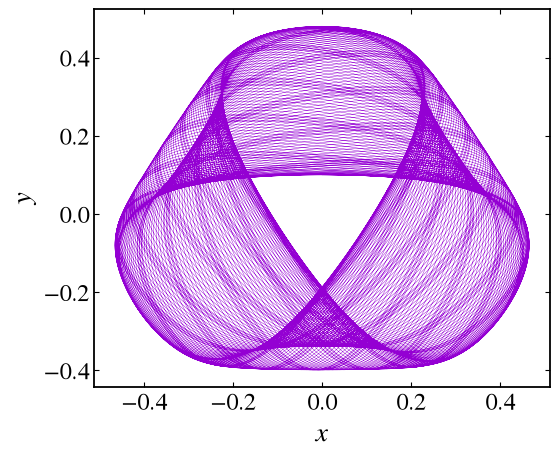

In [14]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(trajectory[:, 1], trajectory[:, 2], color="darkviolet", lw=0.3)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/henon_heiles_trajectory.png",
    dpi=400,
    bbox_inches="tight",
)

## Energy conservation

The quality of a symplectic integrator shows in the energy error. Define the relative energy error $E_r(t) = |E(t)-E_0|/E_0$ and evaluate the Hénon-Heiles Hamiltonian along the trajectory of each integrator. Because Hénon-Heiles is separable, all three integrators apply.

In [15]:
def henon_heiles_energy(trajectory):
    x, y, px, py = (trajectory[:, i] for i in range(1, 5))
    return (px**2 + py**2) / 2 + (x**2 + y**2) / 2 + x**2 * y - y**3 / 3

integrators = {"vv2": "VV2", "imp": "IMP", "svy4": "SVY4"}
histories = {}
for name in integrators:
    if name == "imp":
        system.integrator(name, time_step=0.01, tol=1e-12, max_iter=100)
    else:
        system.integrator(name, time_step=0.01)
    history = system.trajectory(q, p, total_time)
    error = np.abs(henon_heiles_energy(history) - energy) / energy
    histories[name] = (history[:, 0], error)

<Figure size 640x480 with 0 Axes>

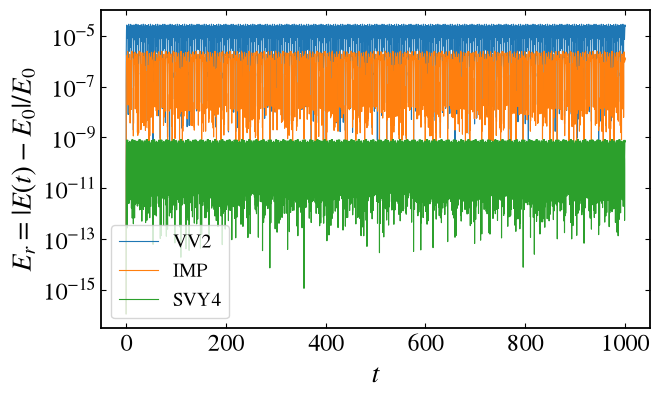

In [16]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, label in integrators.items():
    time, error = histories[name]
    ax.semilogy(time, error, lw=0.8, label=label)
ax.set_xlabel("$t$")
ax.set_ylabel(r"$E_r = |E(t) - E_0| / E_0$")
ax.legend()
fig.tight_layout()
plt.savefig(
    f"{path_figures}/henon_heiles_energy_check.png",
    dpi=400,
    bbox_inches="tight",
)

# Poincaré sections


The `poincare_section` method reduces a continuous Hamiltonian flow to a map by recording the successive crossings of a chosen surface in phase space. For a system with two degrees of freedom at fixed energy, a section through the energy surface produces a two-dimensional picture in which regular and chaotic motion are directly distinguishable, as in the numerical experiments of [Hénon and Heiles (1964)](https://doi.org/10.1086/109234).

## The section and its output

The section is defined by `section_index` (the coordinate whose crossings are recorded) and `section_value` (its value on the surface). The `crossing` argument selects the direction: `1` for upward, `-1` for downward, `0` for both. For an angle variable, set `periodic_section_coordinate=True` and give its `period`.

For a single initial condition the method returns an array of shape `(num_intersections, 2d + 1)` with columns time, the `d` coordinates, and the `d` momenta. Passing a two-dimensional `q` and `p` of shape `(num_ic, d)` evolves an ensemble and returns `(num_ic, num_intersections, 2d + 1)`.

## A section of the Hénon-Heiles system

Take the section at $x=0$ and record upward crossings, so each point is a pair $(y, p_y)$. Fix the energy at $E=1/8$ and build an ensemble of initial conditions on the section: choose $x=0$ and values of $y$ and $p_y$ inside the accessible region, then fix $p_x>0$ from the energy using $V(0,y)=y^2/2-y^3/3$.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem, PlotStyler

system = HamiltonianSystem(model="henon heiles")
system.integrator("svy4", time_step=0.01)

energy = 1 / 8
num_intersections = 2000
num_ic = 250
rng = np.random.default_rng(13121989)

q0 = []
p0 = []
while len(q0) < num_ic:
    y = rng.uniform(-0.5, 0.75)
    py = rng.uniform(-0.6, 0.6)
    potential = y**2 / 2 - y**3 / 3
    discriminant = 2 * (energy - potential) - py**2
    if discriminant > 0:
        q0.append([0.0, y])
        p0.append([np.sqrt(discriminant), py])
q0 = np.array(q0)
p0 = np.array(p0)

sections = system.poincare_section(
    q0,
    p0,
    num_intersections,
    section_index=0,
    section_value=0.0,
    crossing=1,
)

<Figure size 640x480 with 0 Axes>

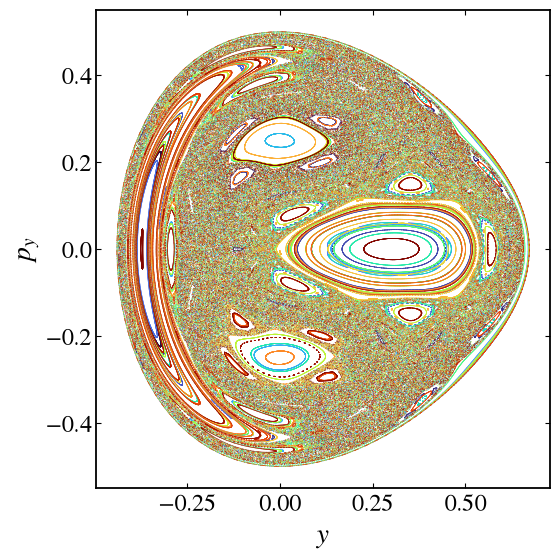

In [34]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(6, 6))
colors = plt.cm.turbo(np.linspace(0, 1, len(sections)))
for section, color in zip(sections, colors):
    ax.scatter(section[:, 2], section[:, 4], s=0.3, color=color, edgecolor="none")
ax.set_xlabel("$y$")
ax.set_ylabel("$p_y$")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/henon_heiles_poincare_section.png",
    dpi=400,
    bbox_inches="tight",
)

## Sectioning on an angle

The section coordinate can be an angle. In an action-angle system the natural surface of section is an angle, which winds continuously and must be treated as periodic. Setting `periodic_section_coordinate=True` uses differences reduced modulo `period` ($2\pi$ by default), so each pass of the angle through `section_value` counts as one crossing and the $2\pi$ wrap does not register a spurious one.

We use the two-resonance Walker-Ford Hamiltonian defined above, with $\alpha=\beta=0.02$, sectioning on $\theta_1=3\pi/2$ at energy $E=0.2$. On the section $H=E$ is quadratic in $J_1$, which is solved in closed form for the positive branch.

In [19]:
import numpy as np

def walker_ford_J1_from_E(q, p, energy, parameters):
    theta1, theta2 = q
    J2 = p[1]
    alpha, beta = parameters

    phase_22 = 2.0 * theta1 - 2.0 * theta2
    phase_23 = 2.0 * theta1 - 3.0 * theta2

    a = -1.0
    b = 1.0 - 3.0 * J2 + alpha * J2 * np.cos(phase_22) + beta * J2**1.5 * np.cos(phase_23)
    c = J2**2 + J2 - energy

    discriminant = b**2 - 4.0 * a * c
    if discriminant < 0.0:
        return np.nan
    J1 = (-b + np.sqrt(discriminant)) / (2.0 * a)
    return J1 if J1 >= 0.0 else np.nan

In [20]:
from pynamicalsys import HamiltonianSystem, PlotStyler

system = HamiltonianSystem(
    eom=walker_ford_eom,
    hess_H=walker_ford_hess_H,
    degrees_of_freedom=2,
    parameters=[0.02, 0.02],
)
parameters = system.get_parameters()
system.integrator("imp", tol=1e-9, max_iter=1000)

In [30]:
import matplotlib.pyplot as plt

energy = 0.2
section_value = 3 * np.pi / 2
num_ic = 100
num_intersections = 2_000
rng = np.random.default_rng(13121989)

theta = np.zeros((num_ic, 2))
J = np.zeros((num_ic, 2))
for i in range(num_ic):
    while True:
        theta2 = rng.uniform(0.0, 2 * np.pi)
        J2 = rng.uniform(0.005, 0.1)
        J1 = walker_ford_J1_from_E([section_value, theta2], [0.0, J2], energy, parameters)
        if not np.isnan(J1):
            theta[i] = [section_value, theta2]
            J[i] = [J1, J2]
            break

In [31]:
sections = system.poincare_section(
    theta,
    J,
    num_intersections,
    section_index=0,
    section_value=section_value,
    crossing=0,
    periodic_section_coordinate=True,
)

<Figure size 640x480 with 0 Axes>

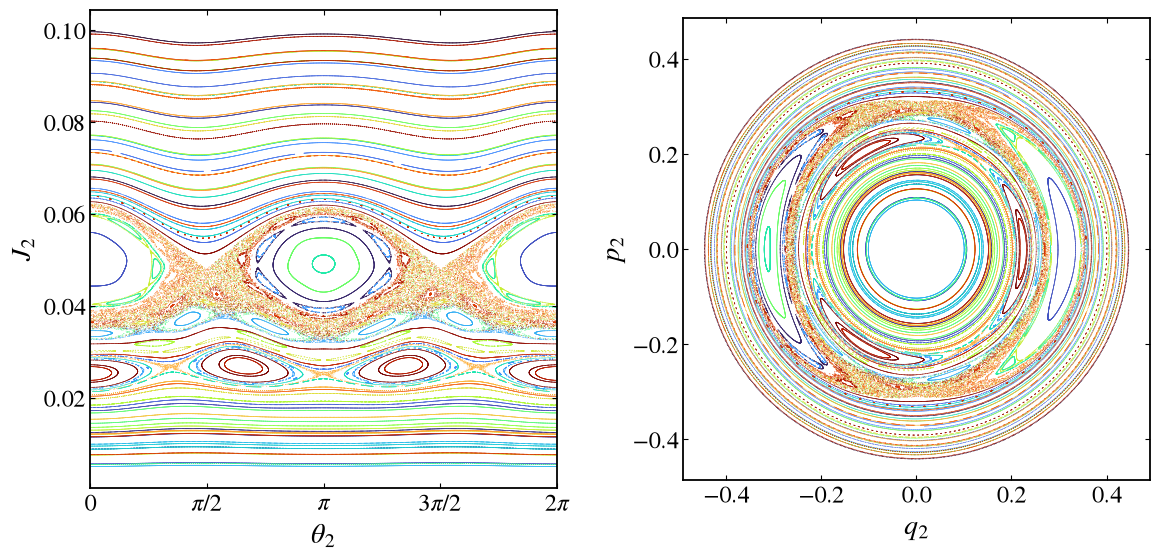

In [32]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
colors = plt.cm.turbo(np.linspace(0, 1, num_ic))
for section, color in zip(sections, colors):
    theta2 = section[:, 2]
    J2 = section[:, 4]
    ax[0].scatter(theta2 % (2 * np.pi), J2, s=0.3, color=color, edgecolor="none")
    q2 = np.sqrt(2 * J2) * np.cos(theta2)
    p2 = -np.sqrt(2 * J2) * np.sin(theta2)
    ax[1].scatter(q2, p2, s=0.3, color=color, edgecolor="none")
ax[0].set_xlabel(r"$\theta_2$")
ax[0].set_ylabel(r"$J_2$")
ax[0].set_xlim(0, 2 * np.pi)
ax[0].set_xticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
ax[0].set_xticklabels(["$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
ax[1].set_xlabel("$q_2$")
ax[1].set_ylabel("$p_2$")
ax[1].set_aspect("equal")
fig.tight_layout()
plt.savefig(
    f"{path_figures}/walker_ford_poincare_section.png",
    dpi=400,
    bbox_inches="tight",
)

# Chaotic indicators


Chaotic indicators quantify instability and the geometry of the tangent dynamics along Hamiltonian trajectories. This section begins with the Lyapunov spectrum, whose symplectic pairing is characteristic of Hamiltonian systems.

## Lyapunov exponents


For a Hamiltonian system a deviation vector $\delta\mathbf{z}$ in the phase space $\mathbf{z}=(\mathbf{q},\mathbf{p})$ evolves under $\dot{\delta\mathbf{z}} = \mathbb{J}\,\nabla^2 H(\mathbf{z})\,\delta\mathbf{z}$, where $\nabla^2 H$ is the Hessian of the Hamiltonian and $\mathbb{J}$ is the symplectic matrix. Because the linearized flow is symplectic, the exponents come in pairs $\pm\lambda$ and the full spectrum sums to zero. The tangent dynamics require the Hessians, which the built-in Hénon-Heiles model provides. The method uses the standard QR algorithm of Shimada and Nagashima and of Benettin et al.

### The Lyapunov spectrum of the Hénon-Heiles system

Fix $E=1/8$ and follow a chaotic orbit ($x=0$, $y=-0.1$, $p_y=0$, $p_x>0$ from the energy). Leaving `num_exponents` at its default returns the full $2f=4$ exponents; keep the convergence history.

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem, PlotStyler

system = HamiltonianSystem(model="henon heiles")
system.integrator("svy4", time_step=0.01)

energy = 1 / 8
x, y, py = 0.0, -0.1, 0.0
potential = (x**2 + y**2) / 2 + x**2 * y - y**3 / 3
px = np.sqrt(2 * (energy - potential) - py**2)

q = [x, y]
p = [px, py]
total_time = 10_000.0

lyapunov_history = system.lyapunov(q, p, total_time, return_history=True)

<Figure size 640x480 with 0 Axes>

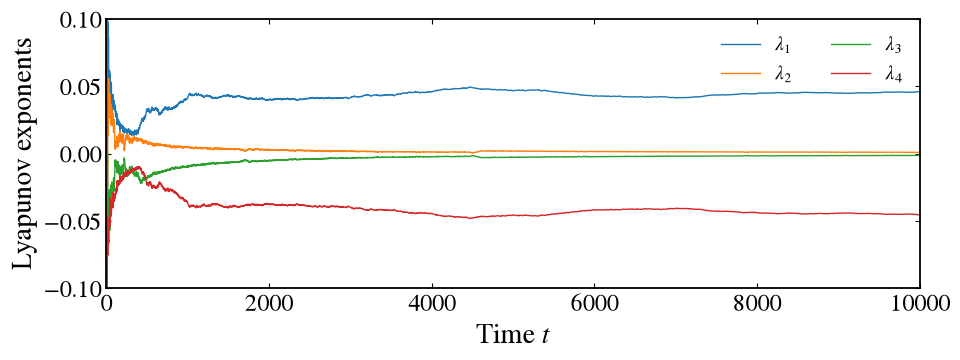

In [39]:
time = lyapunov_history[:, 0]
exponents = lyapunov_history[:, 1:]

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(10, 4))
for index in range(exponents.shape[1]):
    ax.plot(time, exponents[:, index], label=rf"$\lambda_{index + 1}$")
ax.set_xlabel("Time $t$")
ax.set_ylabel("Lyapunov exponents")
ax.set_xlim(0, total_time)
ax.set_ylim(-0.1, 0.1)
ax.legend(loc="upper right", frameon=False, ncol=2)
fig.tight_layout()
plt.savefig(
    f"{path_figures}/henon_heiles_lyapunov.png",
    dpi=400,
    bbox_inches="tight",
)

### The largest exponent as a diagnostic

With `num_exponents=1` the method uses the dedicated single-vector calculation and returns a scalar. Compare the chaotic orbit with the regular orbit at the mirror initial condition $y=+0.1$, which lies on an invariant torus.

In [38]:
def px_from_energy(x, y, py, energy):
    potential = (x**2 + y**2) / 2 + x**2 * y - y**3 / 3
    return np.sqrt(2 * (energy - potential) - py**2)

q_chaotic = [0.0, -0.1]
p_chaotic = [px_from_energy(0.0, -0.1, 0.0, energy), 0.0]
q_regular = [0.0, 0.1]
p_regular = [px_from_energy(0.0, 0.1, 0.0, energy), 0.0]

largest_chaotic = system.lyapunov(q_chaotic, p_chaotic, total_time, num_exponents=1)
largest_regular = system.lyapunov(q_regular, p_regular, total_time, num_exponents=1)
print(largest_chaotic, largest_regular)

0.046030137384321455 0.0007312556036189062


## Covariant Lyapunov vectors

Covariant Lyapunov vectors identify the local tangent directions associated with the Lyapunov exponents. Unlike the orthonormal vectors of a QR calculation, they are generally not orthogonal and transform covariantly with the tangent dynamics. The `CLV` method uses a Ginelli-style algorithm with a forward QR stage and a backward recursion. The tangent dynamics require the Hessians, which the built-in Hénon-Heiles model provides. Because the flow is symplectic, the exponents occur in pairs $\pm\lambda$ and the vectors of $\lambda_i$ and $-\lambda_i$ are dynamically related.

### Computing the CLVs of the Hénon-Heiles system

Follow a chaotic orbit at $E=1/8$ ($x=0$, $y=-0.2$, $p_y=0$, $p_x>0$ from the energy). The array `clvs` has shape `(num_samples, 4, 4)`; `clvs[n, :, i]` is the $i$-th vector at sample $n$, and the matching row of `clv_trajectory` is `[time, x, y, px, py]`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem, PlotStyler

system = HamiltonianSystem(model="henon heiles")
system.integrator("svy4", time_step=0.01)

energy = 1 / 8
x, y, py = 0.0, -0.2, 0.0
potential = (x**2 + y**2) / 2 + x**2 * y - y**3 / 3
px = np.sqrt(2 * (energy - potential) - py**2)

q = [x, y]
p = [px, py]

clvs, clv_trajectory = system.CLV(
    q,
    p,
    2_000.0,
    num_clvs=4,
    tail_time=100.0,
    qr_time_step=0.01,
)

### Angles between covariant directions on a Poincaré section

An angle near zero means the corresponding directions are nearly tangent (non-hyperbolic); an angle near $\pi/2$ means the splitting is strongly transversal. In a Hamiltonian system it is natural to record the angles on a Poincaré section, which `CLV_angles` does with `poincare_section=True`. The `subspaces` argument gives minimum principal angles between groups of vectors and `pairs` gives direct angles between two vectors, both with zero-based indices. The columns of `angles` are the three subspace angles, then the pair angle.

In [3]:
total_time = 1_000_000.0

angles, section = system.CLV_angles(
    q,
    p,
    total_time,
    subspaces=[([0, 1, 2], [3]), ([0], [1, 2, 3]), ([0, 1], [2, 3])],
    pairs=(0, 3),
    warmup_time=1e4,
    tail_time=1e4,
    poincare_section=True,
    section_index=0,
    section_value=0.0,
    crossing=1,
)

<Figure size 640x480 with 0 Axes>

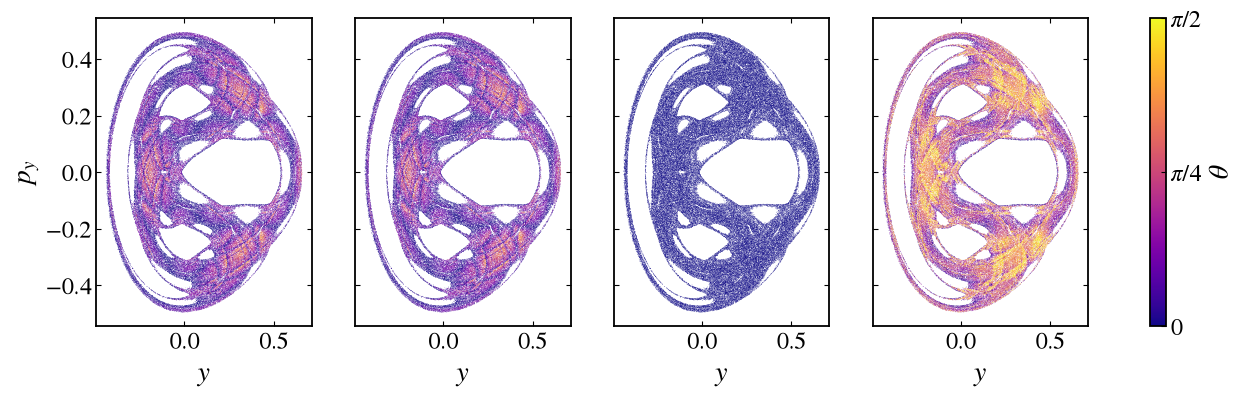

In [7]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(16, 4))
for index in range(4):
    points = ax[index].scatter(
        section[:, 2],
        section[:, 4],
        c=angles[:, index],
        cmap="plasma",
        vmin=0.0,
        vmax=np.pi / 2,
        s=0.1,
        edgecolor="none",
    )
    ax[index].set_xlabel("$y$")
ax[0].set_ylabel("$p_y$")
colorbar = fig.colorbar(points, ax=ax, ticks=[0.0, np.pi / 4, np.pi / 2])
colorbar.set_label(r"$\theta$")
colorbar.set_ticklabels(["$0$", r"$\pi/4$", r"$\pi/2$"])
plt.savefig(
    f"{path_figures}/henon_heiles_clv_angles.png",
    dpi=400,
    bbox_inches="tight",
)

## Alignment indices

The Smaller Alignment Index (SALI), Generalized Alignment Index (GALI), and Linear Dependence Index (LDI) follow normalized deviation vectors under the tangent dynamics to distinguish regular and chaotic motion. SALI is due to [Skokos (2001)](https://doi.org/10.1088/0305-4470/34/47/309), GALI to [Skokos et al. (2007)](https://doi.org/10.1016/j.physd.2007.04.004), and LDI to [Antonopoulos and Bountis (2006)](https://arxiv.org/abs/0711.0360). We use a chaotic Hénon-Heiles orbit at $E=1/8$ with $x=0$, $y=-0.15$, $p_y=0$.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem, PlotStyler

system = HamiltonianSystem(model="henon heiles")
system.integrator("svy4", time_step=0.01)

energy = 1 / 8
x, y, py = 0.0, -0.15, 0.0
potential = (x**2 + y**2) / 2 + x**2 * y - y**3 / 3
px = np.sqrt(2 * (energy - potential) - py**2)

q = [x, y]
p = [px, py]
total_time = 10_000.0
threshold = 1e-16
seed = 1312

### Smaller Alignment Index

SALI $=\min\{\|\hat{\mathbf{v}}_1+\hat{\mathbf{v}}_2\|,\|\hat{\mathbf{v}}_1-\hat{\mathbf{v}}_2\|\}$ decays as $\exp[-(\lambda_1-\lambda_2)t]$ along a chaotic trajectory; for the Hénon-Heiles system $\lambda_2=0$, so the rate is set by $\lambda_1$.

In [10]:
sali_history = system.SALI(
    q,
    p,
    total_time,
    return_history=True,
    threshold=threshold,
    seed=seed,
)

<Figure size 640x480 with 0 Axes>

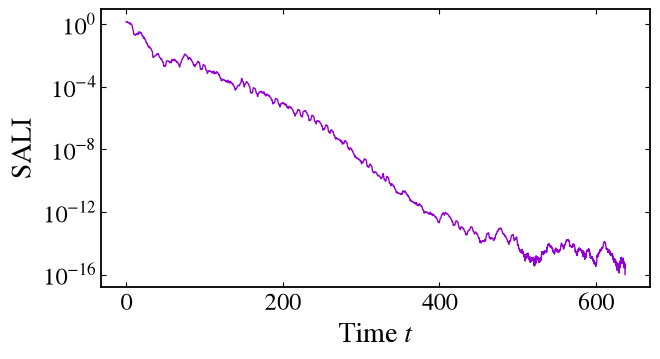

In [11]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(sali_history[:, 0], np.maximum(sali_history[:, 1], threshold), color="darkviolet")
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\mathrm{SALI}$")
fig.tight_layout()
plt.savefig(f"{path_figures}/henon_heiles_sali.png", dpi=400, bbox_inches="tight")

### Generalized Alignment Index

$\mathrm{GALI}_k$ is the volume of the parallelepiped spanned by $k$ normalized deviation vectors and decays faster for larger $k$. The `GALI` method computes it with `method` set to `QR` (default), `QR_HH`, or `DET`. The determinant form loses resolution first, since $\det(\mathbf{V}^T\mathbf{V})=\mathrm{GALI}_2^2$.

In [12]:
gali_methods = ["QR", "QR_HH", "DET"]
gali_method_histories = []
for method in gali_methods:
    gali_method_histories.append(
        system.GALI(q, p, total_time, k=2, return_history=True, method=method, threshold=threshold, seed=seed)
    )

<Figure size 640x480 with 0 Axes>

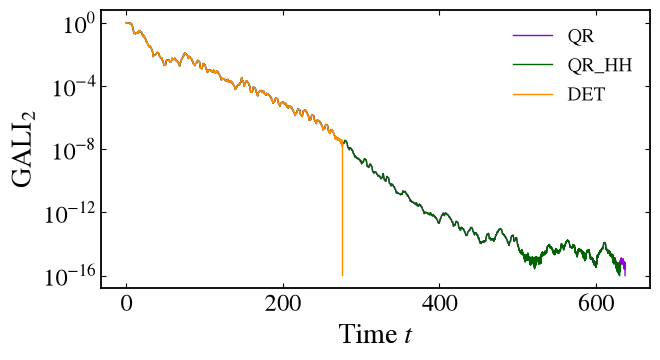

In [13]:
colors = ["darkviolet", "darkgreen", "darkorange"]

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4))
for history, method, color in zip(gali_method_histories, gali_methods, colors):
    ax.semilogy(history[:, 0], np.maximum(history[:, 1], threshold), color=color, label=method)
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\mathrm{GALI}_2$")
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(f"{path_figures}/henon_heiles_gali_methods.png", dpi=400, bbox_inches="tight")

### GALI for different values of k

In [14]:
k_values = np.array([2, 3, 4])
gali_histories = []
for k in k_values:
    gali_histories.append(
        system.GALI(q, p, total_time, k=k, return_history=True, method="QR_HH", threshold=threshold, seed=seed)
    )

<Figure size 640x480 with 0 Axes>

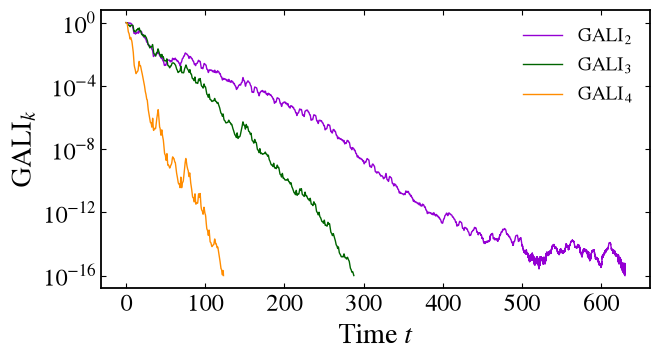

In [15]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4))
for history, k, color in zip(gali_histories, k_values, colors):
    ax.semilogy(history[:, 0], np.maximum(history[:, 1], threshold), color=color, label=rf"$\mathrm{{GALI}}_{k}$")
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\mathrm{GALI}_k$")
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(f"{path_figures}/henon_heiles_gali.png", dpi=400, bbox_inches="tight")

### Linear Dependence Index

$\mathrm{LDI}_k=\prod_{i=1}^{k}\sigma_i$ is the same volume computed from the singular values of the normalized deviation matrix.

In [16]:
ldi_histories = []
for k in k_values:
    ldi_histories.append(
        system.LDI(q, p, total_time, k=k, return_history=True, threshold=threshold, seed=seed)
    )

<Figure size 640x480 with 0 Axes>

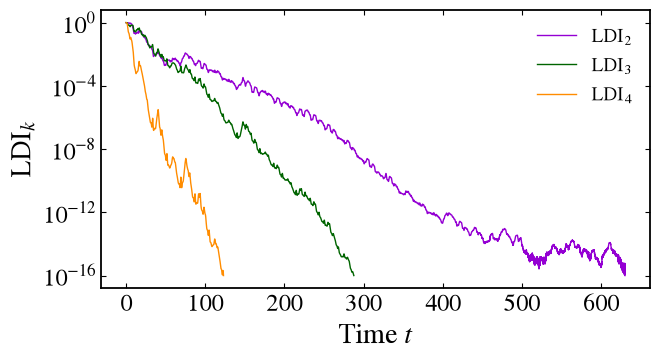

In [17]:
ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(7, 4))
for history, k, color in zip(ldi_histories, k_values, colors):
    ax.semilogy(history[:, 0], np.maximum(history[:, 1], threshold), color=color, label=rf"$\mathrm{{LDI}}_{k}$")
ax.set_xlabel("Time $t$")
ax.set_ylabel(r"$\mathrm{LDI}_k$")
ax.legend(frameon=False)
fig.tight_layout()
plt.savefig(f"{path_figures}/henon_heiles_ldi.png", dpi=400, bbox_inches="tight")

### Correspondence between GALI and LDI

GALI and LDI measure the same volume and are mathematically identical for the same normalized deviation vectors, $\mathrm{GALI}_k=\mathrm{LDI}_k$, an identity derived by [Sales et al. (2026)](https://doi.org/10.1016/j.chaos.2026.117884). GALI uses a determinant or QR factorization, LDI a singular value decomposition.

### Benchmarking the formulations

Compare the wall time of SALI, the three GALI formulations, and LDI along a regular orbit ($y=0.1$, an invariant torus). Setting `threshold=0.0` disables early stopping so each formulation does the full workload; a preliminary call excludes compilation. Absolute times depend on the machine.

<Figure size 640x480 with 0 Axes>

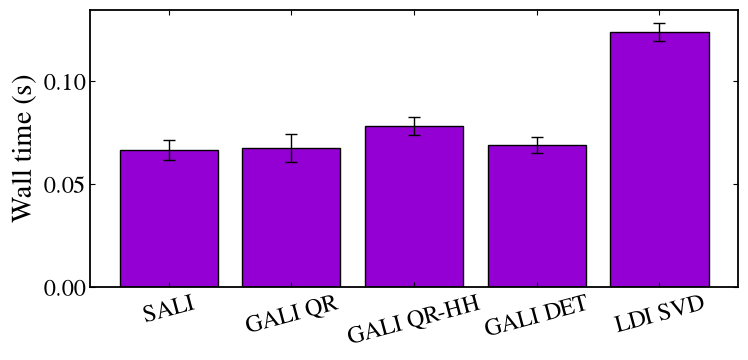

In [18]:
from time import perf_counter

regular_y = 0.1
regular_potential = regular_y**2 / 2 - regular_y**3 / 3
regular_px = np.sqrt(2 * (energy - regular_potential))
regular_q = [0.0, regular_y]
regular_p = [regular_px, 0.0]

benchmark_time = 200.0
benchmark_repeats = 20
benchmark_labels = ["SALI"] + [f"GALI {method.replace('_', '-')}" for method in gali_methods] + ["LDI SVD"]
benchmark_times = np.empty((len(benchmark_labels), benchmark_repeats))

system.SALI(regular_q, regular_p, 1.0, threshold=0.0, seed=seed)
for method in gali_methods:
    system.GALI(regular_q, regular_p, 1.0, k=2, method=method, threshold=0.0, seed=seed)
system.LDI(regular_q, regular_p, 1.0, k=2, threshold=0.0, seed=seed)

for repeat in range(benchmark_repeats):
    start = perf_counter()
    system.SALI(regular_q, regular_p, benchmark_time, threshold=0.0, seed=seed)
    benchmark_times[0, repeat] = perf_counter() - start

    for index, method in enumerate(gali_methods):
        start = perf_counter()
        system.GALI(regular_q, regular_p, benchmark_time, k=2, method=method, threshold=0.0, seed=seed)
        benchmark_times[index + 1, repeat] = perf_counter() - start

    start = perf_counter()
    system.LDI(regular_q, regular_p, benchmark_time, k=2, threshold=0.0, seed=seed)
    benchmark_times[-1, repeat] = perf_counter() - start

mean_times = np.mean(benchmark_times, axis=1)
std_times = np.std(benchmark_times, axis=1, ddof=1)

ps = PlotStyler()
ps.apply_style()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(benchmark_labels, mean_times, yerr=std_times, color="darkviolet", edgecolor="black", linewidth=1.0, capsize=4)
ax.set_ylabel("Wall time (s)")
ax.tick_params(axis="x", labelrotation=15)
fig.tight_layout()
plt.savefig(f"{path_figures}/henon_heiles_alignment_benchmark.png", dpi=400, bbox_inches="tight")

## Recurrence time entropy

`recurrence_time_entropy` measures the diversity of recurrence times in the Poincaré section: it finds nearby pairs within a distance threshold $\varepsilon$ and takes the Shannon entropy of the white vertical-line lengths of the recurrence matrix. Recurrence plots are due to [Eckmann et al. (1987)](https://doi.org/10.1209/0295-5075/4/9/004), the recurrence-period entropy to [Little et al. (2007)](https://doi.org/10.1186/1475-925X-6-23), and the white-line formulation to [Sales et al. (2023)](https://doi.org/10.1063/5.0140613). We compare a quasiperiodic and a chaotic Hénon-Heiles trajectory at $E=1/8$.

### Set up the two trajectories

On the $x=0$ section with $p_y=0$ and $p_x>0$ from the energy, the value of $y$ selects the orbit: $y=0.1$ lies on an invariant torus (quasiperiodic) and $y=-0.15$ lies in the chaotic region. The section records successive upward crossings of $x=0$.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pynamicalsys import HamiltonianSystem, PlotStyler

system = HamiltonianSystem(model="henon heiles")
system.integrator("svy4", time_step=0.01)

energy = 1 / 8

def state_on_section(y):
    potential = y**2 / 2 - y**3 / 3
    px = np.sqrt(2 * (energy - potential))
    return [0.0, y], [px, 0.0]

quasiperiodic_q, quasiperiodic_p = state_on_section(0.1)
chaotic_q, chaotic_p = state_on_section(-0.15)
num_intersections = 2_000

### Standard-deviation threshold

`threshold_mode="std"` with `threshold=0.1` sets $\varepsilon$ to ten percent of the largest coordinate standard deviation in each section.

#### Quasiperiodic trajectory

In [20]:
rte_std_quasiperiodic, matrix_std_quasiperiodic = system.recurrence_time_entropy(
    quasiperiodic_q,
    quasiperiodic_p,
    num_intersections,
    section_index=0,
    section_value=0.0,
    crossing=1,
    threshold_mode="std",
    threshold=0.1,
    metric="supremum",
    std_metric="supremum",
    return_recmat=True,
)

#### Chaotic trajectory

In [21]:
rte_std_chaotic, matrix_std_chaotic = system.recurrence_time_entropy(
    chaotic_q,
    chaotic_p,
    num_intersections,
    section_index=0,
    section_value=0.0,
    crossing=1,
    threshold_mode="std",
    threshold=0.1,
    metric="supremum",
    std_metric="supremum",
    return_recmat=True,
)

### Fixed recurrence rate

`threshold_mode="rr"` with `threshold=0.05` chooses $\varepsilon$ separately for each trajectory to target an off-diagonal recurrence rate of five percent.

#### Quasiperiodic trajectory

In [25]:
rte_rr_quasiperiodic, matrix_rr_quasiperiodic = system.recurrence_time_entropy(
    quasiperiodic_q,
    quasiperiodic_p,
    num_intersections,
    section_index=0,
    section_value=0.0,
    crossing=1,
    threshold_mode="rr",
    threshold=0.01,
    metric="supremum",
    return_recmat=True,
)

#### Chaotic trajectory

In [26]:
rte_rr_chaotic, matrix_rr_chaotic = system.recurrence_time_entropy(
    chaotic_q,
    chaotic_p,
    num_intersections,
    section_index=0,
    section_value=0.0,
    crossing=1,
    threshold_mode="rr",
    threshold=0.01,
    metric="supremum",
    return_recmat=True,
)

### Compare each matrix with its RTE

The top row is the quasiperiodic trajectory and the bottom row the chaotic one; the columns are the standard-deviation and fixed-RR thresholds. Plot the entries with $R_{ij}=1$; each title shows the RTE.

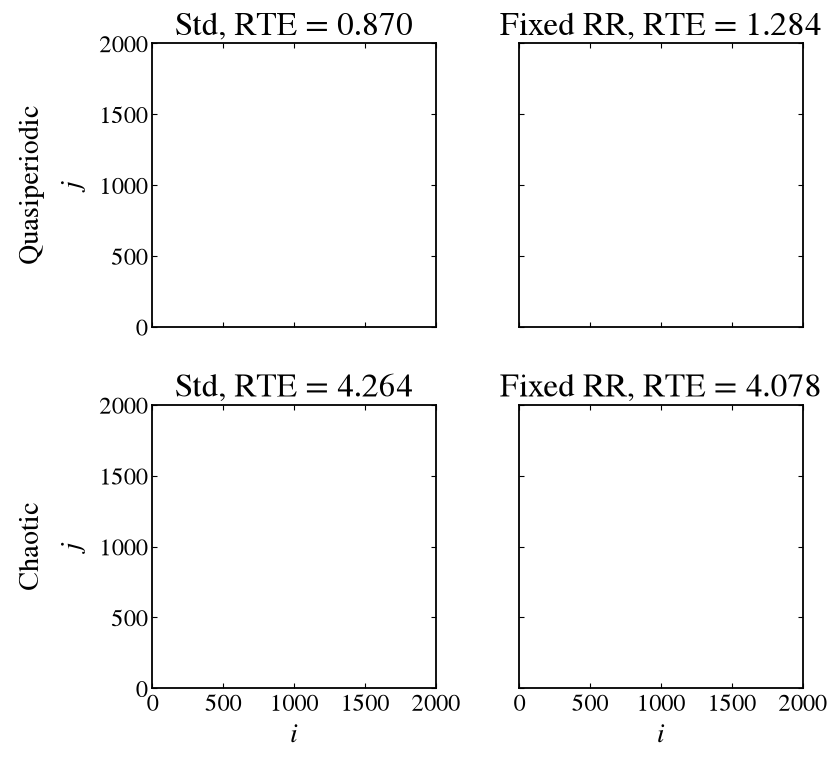

In [27]:
ps = PlotStyler()
ps.apply_style()
plt.close()

fig, ax = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True)
j, i = np.where(matrix_std_quasiperiodic == 1)
ax[0, 0].scatter(i, j, s=0.05, c="black", marker="s", linewidths=0)
j, i = np.where(matrix_rr_quasiperiodic == 1)
ax[0, 1].scatter(i, j, s=0.05, c="black", marker="s", linewidths=0)
j, i = np.where(matrix_std_chaotic == 1)
ax[1, 0].scatter(i, j, s=0.05, c="black", marker="s", linewidths=0)
j, i = np.where(matrix_rr_chaotic == 1)
ax[1, 1].scatter(i, j, s=0.05, c="black", marker="s", linewidths=0)
ax[0, 0].set_xlim(0, num_intersections)
ax[0, 0].set_ylim(0, num_intersections)
for a in ax.ravel():
    a.set_aspect("equal")
ax[0, 0].set_title(f"Std, RTE = {rte_std_quasiperiodic:.3f}")
ax[0, 1].set_title(f"Fixed RR, RTE = {rte_rr_quasiperiodic:.3f}")
ax[1, 0].set_title(f"Std, RTE = {rte_std_chaotic:.3f}")
ax[1, 1].set_title(f"Fixed RR, RTE = {rte_rr_chaotic:.3f}")
ax[0, 0].set_ylabel("Quasiperiodic\n$j$")
ax[1, 0].set_ylabel("Chaotic\n$j$")
ax[1, 0].set_xlabel("$i$")
ax[1, 1].set_xlabel("$i$")
fig.tight_layout()
plt.savefig(f"{path_figures}/henon_heiles_rte_thresholds.png", dpi=400, bbox_inches="tight")

### Other section and output options

The section is selected with `section_index`, `section_value`, `crossing`, and `periodic_section_coordinate`. `threshold_mode="direct"` uses an absolute threshold; `lmin` sets the shortest accepted white line; `return_final_state=True` and `return_p=True` add the final section point and the normalized white-line distribution, in the order final point, recurrence matrix, distribution. A recurrence matrix for $N$ section points has $N^2$ entries.